# Day 5: Neural-Behavioral Integration - Head Direction Cells

## Learning Objectives

By the end of this session, you will be able to:

1. **Load and explore** neural data from NWB (Neurodata Without Borders) files using pynapple
2. **Compute and visualize** head direction tuning curves for neural populations
3. **Calculate egocentric boundary representations** from allocentric positions and head direction
4. **Analyze state-dependent** neural responses (e.g., proximity to borders, behavioral states)
5. **Integrate behavioral and neural data** to test hypotheses about neural coding

---

## Overview: Linking Neural Activity to Behavior

Throughout this workshop, we've focused on **behavior** - extracting features, segmenting trajectories, and discovering behavioral states. But behavior doesn't happen in a vacuum; it's driven by neural activity.

Today, we'll bridge the gap between **behavior** and **brain** by analyzing **head direction (HD) cells** - neurons that fire when an animal faces a specific direction. You can explore:

- How HD cells encode directional information in **allocentric** (world-centered) coordinates
- How to transform this into **egocentric** (body-centered) representations
- How behavioral states (e.g., proximity to walls) modulate neural responses

### What are Head Direction Cells?

Head direction cells act like a "neural compass" - each cell fires maximally when the animal faces a particular direction (its **preferred direction**). They're found in several brain regions including:

- **Postsubiculum** (dorsal presubiculum)
- **Anterior dorsal thalamus**
- **Retrosplenial cortex**

These cells maintain stable representations across environments and are crucial for **spatial navigation**.

---

## Setup

First, let's install and import the necessary libraries.

In [2]:
# Install required packages
!pip install pynapple matplotlib numpy scipy xarray -q

# Note: In Colab, pynapple can read NWB files directly
# If you need to install pynwb separately:
# !pip install pynwb -q

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage
from scipy import stats
import pynapple as nap
import xarray as xr
import pandas as pd
from tqdm import tqdm

# Set plotting style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ All libraries imported successfully!")
print(f"Pynapple version: {nap.__version__}")

✓ All libraries imported successfully!
Pynapple version: 0.10.3


---

# Part 1: Loading and Exploring Neural Data

## 1.1 Understanding the NWB Data Structure

The **Neurodata Without Borders (NWB)** format is a standardized format for storing neuroscience data. Our file contains:

- **Behavioral tracking data**: x, y, z positions and orientation (roll, yaw, pitch)
- **Neural recordings**: Spike times from multiple neurons (units)
- **Metadata**: Information about the recording session, arena, and cell types

Let's load the data and explore its structure.

In [3]:
# Load the NWB file using pynapple
# Note: Replace this path with the actual path to your data
# For example, if mounted in Google Drive:
# data_path = '/content/drive/MyDrive/workshop_data/area-pos_sub-normalA3717_ses-201021_epoch-0.nwb'

import urllib.request
import os

# # Create data directory
# os.makedirs('data', exist_ok=True)
!curl -sO https://raw.githubusercontent.com/miaowangcissy/animal_behavior_analysis_in_python/main/data/mouse_foraging/area-pos_sub-normalA3717_ses-201021_epoch-0.nwb
data_path = 'area-pos_sub-normalA3717_ses-201021_epoch-0.nwb'

# Load the session
this_session = nap.load_file(data_path)

print("Session loaded successfully!")
print(f"\nSession name: {this_session.name}")
print(f"Session description: {this_session.nwb.session_description}")

Session loaded successfully!

Session name: area-pos_sub-normalA3717_ses-201021_epoch-0
Session description: Epoch 0 from Session A3717-201021. Arena shape: square. Border parameters: p0_x:-0.2385824,p0_y:-0.0771792,p1_x:-0.2385824,p1_y:0.7785472000000001,p2_x:0.6119824,p2_y:-0.0771792,p3_x:0.6119824,p3_y:0.7785472000000001


In [ ]:
print(this_session)

area-pos_sub-normalA3717_ses-201021_epoch-0
┍━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys            │ Type        │
┝━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units           │ TsGroup     │
│ epoch           │ IntervalSet │
│ z               │ Tsd         │
│ y               │ Tsd         │
│ x               │ Tsd         │
│ rz              │ Tsd         │
│ ry              │ Tsd         │
│ rx              │ Tsd         │
│ distance_border │ Tsd         │
┕━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙


### Exploring the Data Structure

The NWB file contains several components. Let's examine what's available:

In [6]:
# Print the available keys in the session
print("Available data components:")
print(list(this_session.keys()))

# Examine the behavioral data
print("\n" + "="*60)
print("BEHAVIORAL DATA")
print("="*60)

# Position data
print("\nX position:")
print(this_session['x'])

print("\nY position:")
print(this_session['y'])

# Orientation data (Euler angles)
print("\nYaw angle (head direction):")
print(this_session['ry'])  # ry = yaw = head direction

# Neural data
print("\n" + "="*60)
print("NEURAL DATA")
print("="*60)
print("\nNeurons (units):")
print(this_session['units'])

# Check if HD cell classification is available
if 'hd_type' in this_session['units'].metadata.columns:
    print("\n✓ HD cell classification is available!")
    print("\nUnit metadata columns:")
    print(this_session['units'].metadata.columns.tolist())
else:
    print("\n⚠ No HD cell classification in metadata")

Available data components:
['units', 'epoch', 'z', 'y', 'x', 'rz', 'ry', 'rx', 'distance_border']

BEHAVIORAL DATA

X position:
Time (s)
----------  --------
4389.914    0.374485
4389.924    0.375331
4389.934    0.376606
4389.944    0.377838
4389.954    0.379082
4389.964    0.380328
4389.974    0.38164
...
6193.814    0.25195
6193.824    0.25164
6193.834    0.251346
6193.844    0.251045
6193.854    0.25072
6193.864    0.250373
6193.874    0.250083
dtype: float64, shape: (180407,)

Y position:
Time (s)
----------  ---------
4389.914    0.0651296
4389.924    0.0654032
4389.934    0.065912
4389.944    0.0665504
4389.954    0.0672768
4389.964    0.0679568
4389.974    0.0686576
...
6193.814    0.0746512
6193.824    0.0745568
6193.834    0.0745488
6193.844    0.0746032
6193.854    0.074696
6193.864    0.0748288
6193.874    0.0749312
dtype: float64, shape: (180407,)

Yaw angle (head direction):
Time (s)
----------  --------
4389.914     5.8446
4389.924     5.7227
4389.934     5.4358
4389.944 

### Arena Geometry

The session description contains information about the arena boundaries. Let's extract this information:

In [7]:
# Extract arena information from session description
session_desc = this_session.nwb.session_description
print(f"Session description: {session_desc}")

# Parse the arena boundaries
# The description format: "Arena shape: square. Border parameters: p0_x:..., p0_y:..., etc."
import re

# Extract corner coordinates
corners = {}
for i in range(4):
    x_match = re.search(f'p{i}_x:([\-0-9.]+)', session_desc)
    y_match = re.search(f'p{i}_y:([\-0-9.]+)', session_desc)
    
    if x_match and y_match:
        corners[f'p{i}'] = {
            'x': float(x_match.group(1)),
            'y': float(y_match.group(1))
        }

print("\nArena corners:")
for corner, coords in corners.items():
    print(f"{corner}: x={coords['x']:.4f} m, y={coords['y']:.4f} m")

# Define arena boundaries for later use
# For a rectangular arena, we need: x_min, x_max, y_min, y_max
x_coords = [corners[f'p{i}']['x'] for i in range(4)]
y_coords = [corners[f'p{i}']['y'] for i in range(4)]

arena_bounds = {
    'x_min': min(x_coords),
    'x_max': max(x_coords),
    'y_min': min(y_coords),
    'y_max': max(y_coords)
}

print("\nArena boundaries (meters):")
for key, val in arena_bounds.items():
    print(f"{key}: {val:.4f}")

Session description: Epoch 0 from Session A3717-201021. Arena shape: square. Border parameters: p0_x:-0.2385824,p0_y:-0.0771792,p1_x:-0.2385824,p1_y:0.7785472000000001,p2_x:0.6119824,p2_y:-0.0771792,p3_x:0.6119824,p3_y:0.7785472000000001

Arena corners:
p0: x=-0.2386 m, y=-0.0772 m
p1: x=-0.2386 m, y=0.7785 m
p2: x=0.6120 m, y=-0.0772 m
p3: x=0.6120 m, y=0.7785 m

Arena boundaries (meters):
x_min: -0.2386
x_max: 0.6120
y_min: -0.0772
y_max: 0.7785


<>:12: SyntaxWarning: invalid escape sequence '\-'
<>:13: SyntaxWarning: invalid escape sequence '\-'
<>:12: SyntaxWarning: invalid escape sequence '\-'
<>:13: SyntaxWarning: invalid escape sequence '\-'
/var/folders/rm/m418549n60ldjvfgbchrnp8r0000gn/T/ipykernel_30496/4100601767.py:12: SyntaxWarning: invalid escape sequence '\-'
  x_match = re.search(f'p{i}_x:([\-0-9.]+)', session_desc)
/var/folders/rm/m418549n60ldjvfgbchrnp8r0000gn/T/ipykernel_30496/4100601767.py:13: SyntaxWarning: invalid escape sequence '\-'
  y_match = re.search(f'p{i}_y:([\-0-9.]+)', session_desc)


### Visualize the Trajectory

Let's plot the animal's movement path in the arena:

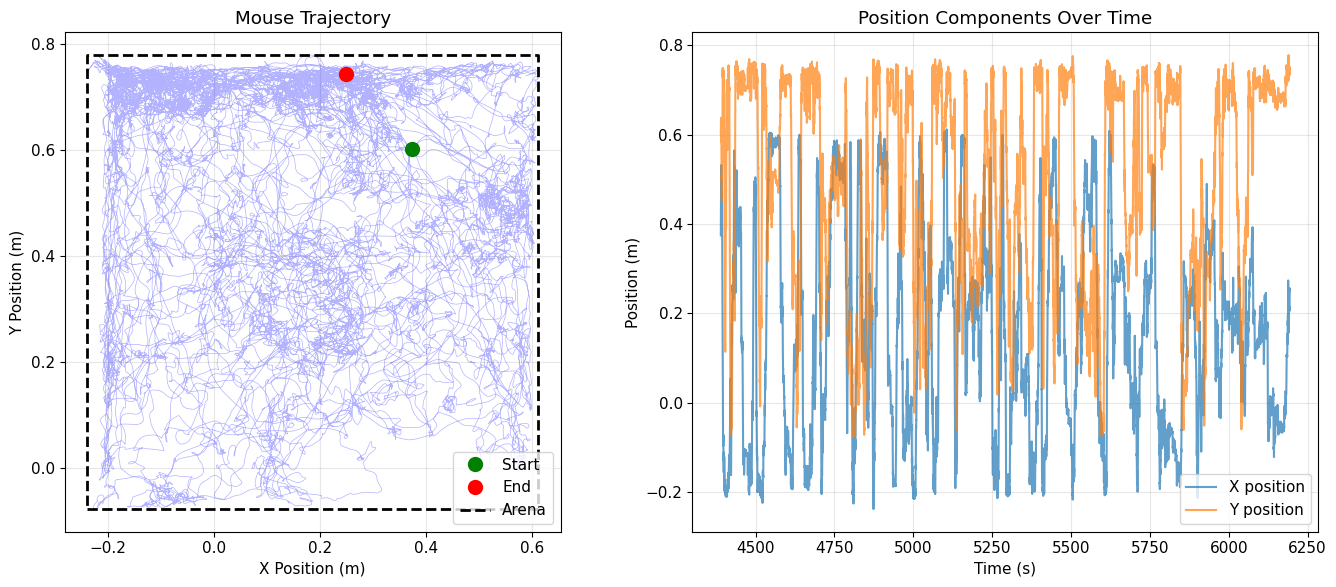


Session duration: 1803.96 seconds
Number of tracking samples: 180407
Sampling rate: ~100.0 Hz


In [8]:
# Get position data
x_pos = this_session['x']
y_pos = this_session['z']
time = this_session['x'].index

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: Full trajectory
ax1 = axes[0]
ax1.plot(x_pos, y_pos, 'b-', alpha=0.3, linewidth=0.5)
ax1.plot(x_pos[0], y_pos[0], 'go', markersize=10, label='Start')
ax1.plot(x_pos[-1], y_pos[-1], 'ro', markersize=10, label='End')

# Draw arena boundaries
arena_x = [arena_bounds['x_min'], arena_bounds['x_max'], 
           arena_bounds['x_max'], arena_bounds['x_min'], arena_bounds['x_min']]
arena_y = [arena_bounds['y_min'], arena_bounds['y_min'], 
           arena_bounds['y_max'], arena_bounds['y_max'], arena_bounds['y_min']]
ax1.plot(arena_x, arena_y, 'k--', linewidth=2, label='Arena')

ax1.set_xlabel('X Position (m)')
ax1.set_ylabel('Y Position (m)')
ax1.set_title('Mouse Trajectory')
ax1.legend()
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# Right panel: Position over time
ax2 = axes[1]
ax2.plot(time, x_pos, label='X position', alpha=0.7)
ax2.plot(time, y_pos, label='Y position', alpha=0.7)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Position (m)')
ax2.set_title('Position Components Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSession duration: {time[-1] - time[0]:.2f} seconds")
print(f"Number of tracking samples: {len(time)}")
print(f"Sampling rate: ~{len(time)/(time[-1] - time[0]):.1f} Hz")

### Visualize Head Direction

Let's look at the head direction (yaw angle) over time:

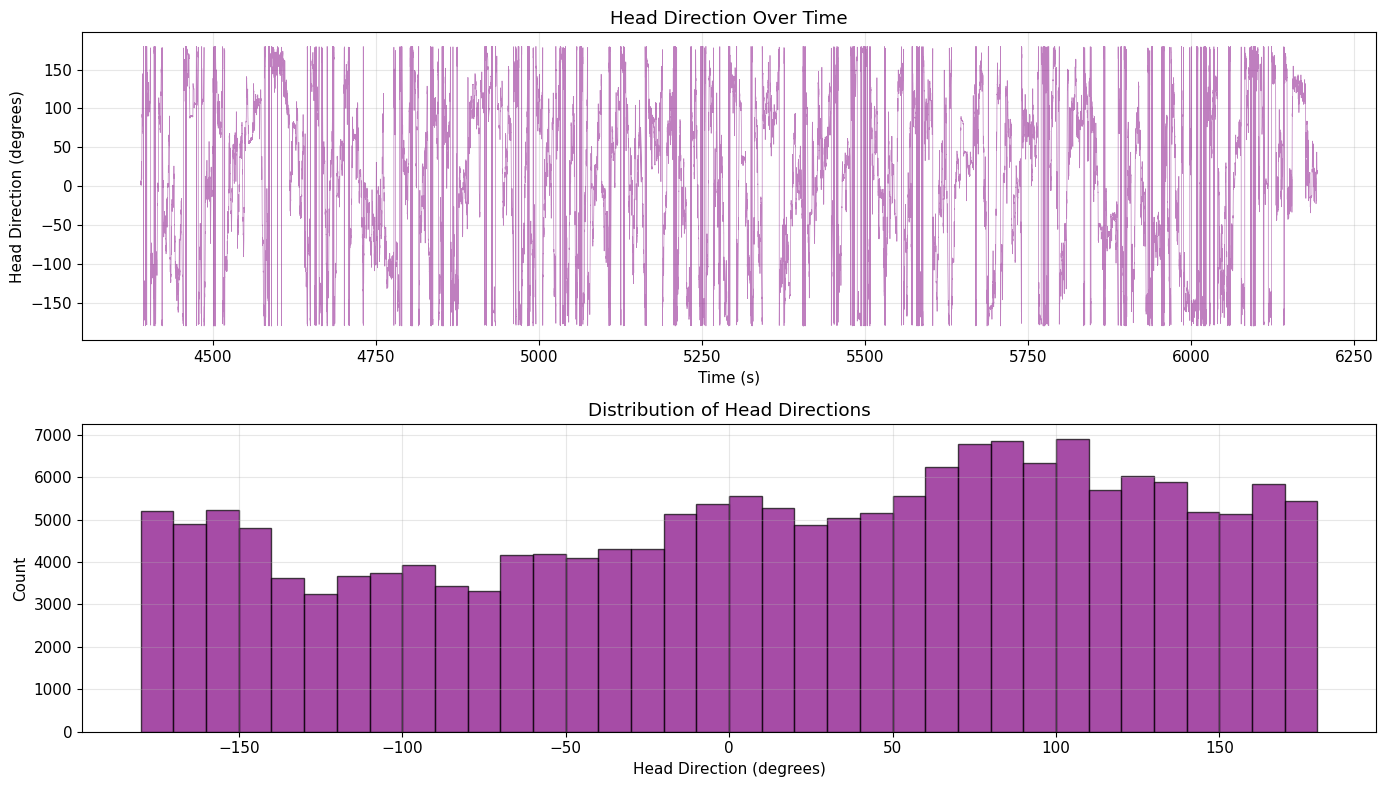

Head direction range: -180.0° to 180.0°
Mean head direction: 14.1°
Std head direction: 103.6°


In [10]:
# Get yaw angle (head direction)
yaw = this_session['ry']  # in degrees

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top panel: Head direction over time
ax1 = axes[0]
ax1.plot(time, yaw, 'purple', alpha=0.5, linewidth=0.5)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Head Direction (degrees)')
ax1.set_title('Head Direction Over Time')
ax1.grid(True, alpha=0.3)

# Bottom panel: Histogram of head directions
ax2 = axes[1]
ax2.hist(yaw, bins=36, edgecolor='black', alpha=0.7, color='purple')
ax2.set_xlabel('Head Direction (degrees)')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Head Directions')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"Head direction range: {yaw.min():.1f}° to {yaw.max():.1f}°")
print(f"Mean head direction: {yaw.mean():.1f}°")
print(f"Std head direction: {yaw.std():.1f}°")

---

# Part 2: Computing Head Direction Tuning Curves

## 2.1 What is a Tuning Curve?

A **tuning curve** shows how a neuron's firing rate varies with a specific variable (in this case, head direction). For head direction cells:

- **X-axis**: Head direction (0° to 360°)
- **Y-axis**: Firing rate (spikes/second)

Each HD cell has a **preferred direction** where it fires maximally.

### Mathematical Definition

The tuning curve $f(\theta)$ at direction $\theta$ is computed as:

$$f(\theta) = \frac{\text{Number of spikes when heading } \theta}{\text{Time spent heading } \theta}$$

In practice, we:
1. Bin the head directions (e.g., 12° bins)
2. Count spikes in each bin
3. Divide by time spent in each bin
4. Smooth the result

## 2.2 Computing Tuning Curves with Pynapple

Pynapple provides a convenient function `compute_tuning_curves()` that handles all of this automatically!

In [11]:
# Get neural data
units = this_session['units']
print(f"Total number of recorded neurons: {len(units)}")

# Filter for head direction cells if classification is available
if 'hd_type' in units.metadata.columns:
    # Get HD cells (assuming 1 = HD cell, 0 = non-HD cell)
    hd_units = units.getby_category('hd_type')[1]
    print(f"Number of classified HD cells: {len(hd_units)}")
else:
    # Use all units if no classification
    hd_units = units
    print("Using all units (no HD classification available)")

# Convert head direction to radians and normalize to [0, 2π]
yaw_rad = np.deg2rad(this_session['ry'] % 360)

# Create a pynapple Tsd (time series data) object
head_direction = nap.Tsd(
    t=this_session['ry'].index.values,
    d=yaw_rad,
    time_units='s'
)

print(f"\nHead direction data:")
print(head_direction)

Total number of recorded neurons: 98
Number of classified HD cells: 59

Head direction data:
Time (s)
----------  ---------
4389.914    0.102007
4389.924    0.09988
4389.934    0.0948726
4389.944    0.0904011
4389.954    0.0973316
4389.964    0.107901
4389.974    0.116311
...
6193.814    0.325485
6193.824    0.32749
6193.834    0.325078
6193.844    0.322581
6193.854    0.318425
6193.864    0.312914
6193.874    0.308266
dtype: float64, shape: (180407,)


/Users/miao/miniconda3/envs/eco/lib/python3.13/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tsd'.
  warnings.warn(


In [12]:
# Compute tuning curves
print("Computing tuning curves...")

tuning_curves = nap.compute_tuning_curves(
    data=hd_units,              # Neural spike data
    features=head_direction,       # Head direction feature
    bins=31,                   # Number of direction bins
    range=(0, 2*np.pi)  ,         # Range: 0 to 360 degrees (in radians)
    feature_names=['head_direction']
)

print(f"✓ Tuning curves computed for {len(tuning_curves)} neurons")
print(f"\nTuning curve shape: {tuning_curves.shape}")
print(f"\nFirst few neurons:")
print(tuning_curves.head())

Computing tuning curves...
✓ Tuning curves computed for 59 neurons

Tuning curve shape: (59, 31)

First few neurons:
<xarray.DataArray (unit: 5, head_direction: 5)> Size: 200B
array([[0.07876933, 0.03235902, 0.        , 0.01714773, 0.03201714],
       [0.34658506, 0.16179509, 0.08747861, 0.10288636, 0.14407714],
       [0.89797038, 0.85751396, 1.32967482, 2.26349995, 6.083257  ],
       [0.34658506, 0.63100084, 0.57735881, 1.90339769, 8.93278265],
       [0.34658506, 0.59864182, 0.8222989 , 1.1488977 , 0.97652283]])
Coordinates:
  * unit            (unit) int64 40B 0 4 5 6 7
  * head_direction  (head_direction) float64 40B 0.1013 0.304 ... 0.7094 0.9121
Attributes:
    occupancy:  [6348. 6181. 5716. 5832. 6247. 7194. 8031. 7761. 7450. 7289. ...
    bin_edges:  [array([0.        , 0.2026834 , 0.40536679, 0.60805019, 0.810...
    fs:         100.00554336016319
    rates:      [1.34925386 2.87090623 4.06993503 4.70298676 2.47566465 3.697...


### Smoothing Tuning Curves

Raw tuning curves can be noisy. We apply **Gaussian smoothing** to reveal the underlying pattern. 

**Important**: For circular variables (like head direction), we use `mode='wrap'` to ensure smoothness across the 0°/360° boundary.

In [13]:
# Apply Gaussian smoothing
smoothed_tuning = tuning_curves.copy()

smoothed_tuning.values = scipy.ndimage.gaussian_filter1d(
    tuning_curves.values, 
    sigma=3, 
    axis=1, 
    mode="wrap" # important for circular variables!
)
                

## 2.3 Visualizing Tuning Curves

Now for the exciting part - let's visualize these tuning curves! We'll use **polar plots** because head direction is circular.

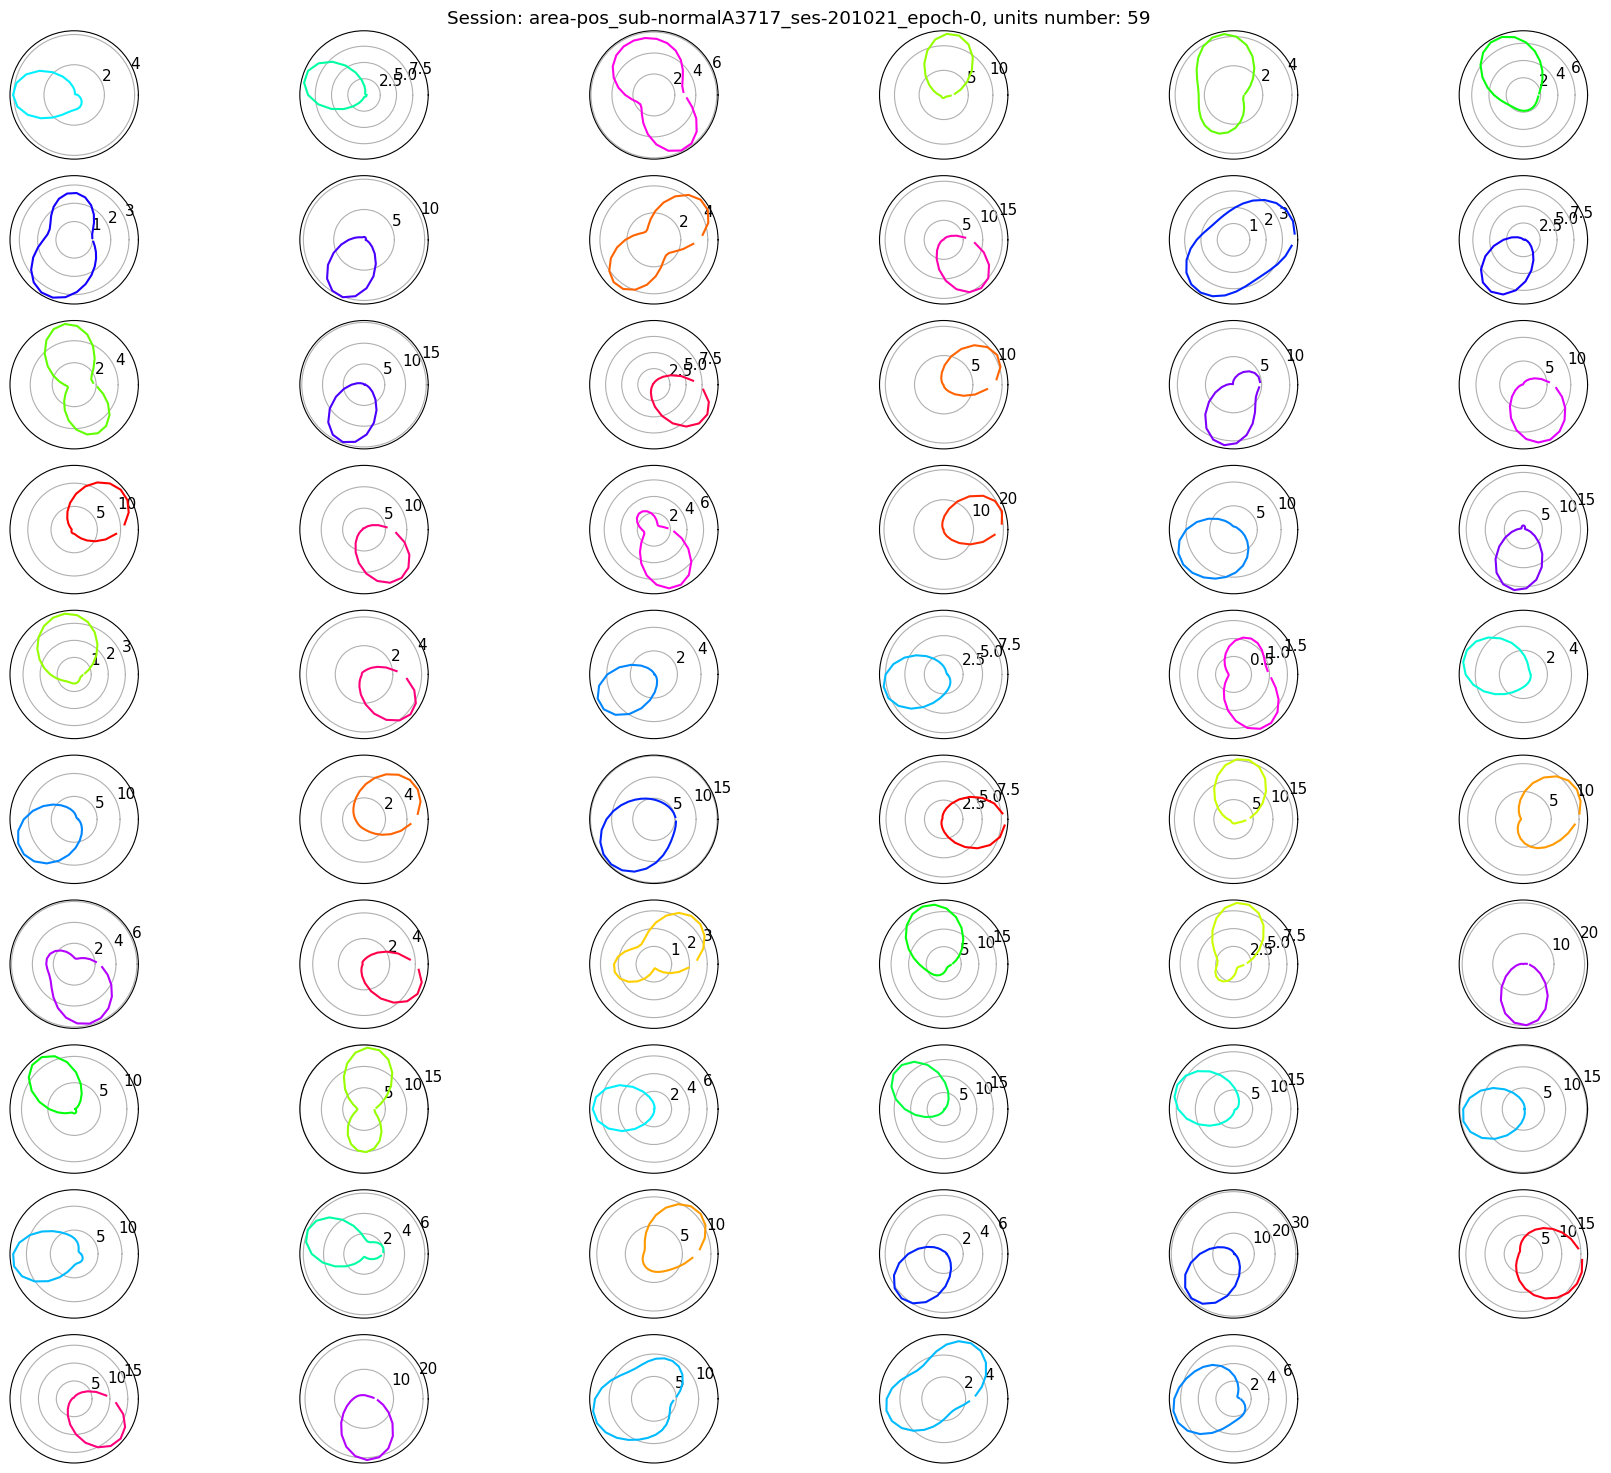

In [14]:
pref_ang = tuning_curves.idxmax(dim = 'head_direction')
norm = plt.Normalize()
color = plt.cm.hsv(norm([i / (2*np.pi) for i in pref_ang.values]))
color = xr.DataArray(
    color, 
    dims=("unit", "color"),
    coords={"unit": pref_ang.unit}
)
rows = len(pref_ang) // 6 + 1
fig = plt.figure(figsize=(18, rows * 1.5))
sorted_tuning_curves = smoothed_tuning.sortby(pref_ang)
for i, n in enumerate(smoothed_tuning.coords["unit"]):
    # Plot the curves in 8 rows and 4 columns
    plt.subplot(rows, 6, i + 1, projection='polar')
    plt.plot(
        sorted_tuning_curves.coords["head_direction"], 
        sorted_tuning_curves.sel(unit=n).values,
        color=color.sel(unit=n).values
    )  # Colour of the curves determined by preferred angle    
    plt.xticks([])

plt.suptitle(f"Session: {this_session.name}, units number: {len(pref_ang)}")
plt.tight_layout()

---

# Part 3: Egocentric Boundary Calculations

## 3.1 Allocentric vs. Egocentric Coordinates

So far, we've been working in **allocentric** (world-centered) coordinates:
- Position: (x, y) in the arena
- Head direction: angle relative to fixed compass (e.g., North)

But animals might also represent space in **egocentric** (body-centered) coordinates:
- "There's a wall 20 cm to my left"
- "The corner is 45° to my right, 50 cm away"

**Question**: Do HD cells also encode egocentric boundary information?

### The Transformation

To compute egocentric coordinates:

1. **For each wall**, compute:
   - Distance from animal to wall
   - Angle from animal's heading to wall

2. **Transform from allocentric to egocentric**:
   - Rotate coordinates by head direction
   - Compute bearing (angle) and distance

Let's implement this!

## 3.2 Computing Distance to Walls

In [15]:
def distance_to_wall(x, y, wall_coords):
    """
    Compute perpendicular distance from point to wall.
    
    Parameters:
    -----------
    x, y : float or array
        Position(s) to compute distance from
    wall_coords : dict
        Wall definition with 'x1', 'y1', 'x2', 'y2' (start and end points)
    
    Returns:
    --------
    distance : float or array
        Perpendicular distance to wall
    """
    # Wall vector
    dx_wall = wall_coords['x2'] - wall_coords['x1']
    dy_wall = wall_coords['y2'] - wall_coords['y1']
    
    # Normalize wall vector
    wall_length = np.sqrt(dx_wall**2 + dy_wall**2)
    
    # Point vector (from wall start to point)
    dx_point = x - wall_coords['x1']
    dy_point = y - wall_coords['y1']
    
    # Project point onto wall
    t = (dx_point * dx_wall + dy_point * dy_wall) / (wall_length**2)
    t = np.clip(t, 0, 1)  # Clamp to wall segment
    
    # Closest point on wall
    closest_x = wall_coords['x1'] + t * dx_wall
    closest_y = wall_coords['y1'] + t * dy_wall
    
    # Distance
    distance = np.sqrt((x - closest_x)**2 + (y - closest_y)**2)
    
    return distance, closest_x, closest_y

# Define the four walls of our rectangular arena
walls = {
    'north': {'x1': arena_bounds['x_min'], 'y1': arena_bounds['y_max'],
              'x2': arena_bounds['x_max'], 'y2': arena_bounds['y_max']},
    'south': {'x1': arena_bounds['x_min'], 'y1': arena_bounds['y_min'],
              'x2': arena_bounds['x_max'], 'y2': arena_bounds['y_min']},
    'east':  {'x1': arena_bounds['x_max'], 'y1': arena_bounds['y_min'],
              'x2': arena_bounds['x_max'], 'y2': arena_bounds['y_max']},
    'west':  {'x1': arena_bounds['x_min'], 'y1': arena_bounds['y_min'],
              'x2': arena_bounds['x_min'], 'y2': arena_bounds['y_max']}
}

# Compute distance to each wall for all positions
wall_distances = {}

for wall_name, wall_coords in walls.items():
    dist, _, _ = distance_to_wall(np.array(x_pos), np.array(y_pos), wall_coords)
    wall_distances[wall_name] = dist

# Find closest wall at each timepoint
closest_wall_dist = np.min(list(wall_distances.values()), axis=0)

print("Distance to walls computed!")
print(f"\nMinimum distance to any wall: {closest_wall_dist.min():.4f} m")
print(f"Maximum distance to any wall: {closest_wall_dist.max():.4f} m")
print(f"Mean distance to closest wall: {closest_wall_dist.mean():.4f} m")

Distance to walls computed!

Minimum distance to any wall: 0.0000 m
Maximum distance to any wall: 0.4247 m
Mean distance to closest wall: 0.1350 m


/var/folders/rm/m418549n60ldjvfgbchrnp8r0000gn/T/ipykernel_30496/2753596821.py:57: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  dist, _, _ = distance_to_wall(np.array(x_pos), np.array(y_pos), wall_coords)


In [16]:
a = np.array(x_pos)

/var/folders/rm/m418549n60ldjvfgbchrnp8r0000gn/T/ipykernel_30496/234454905.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  a = np.array(x_pos)


In [17]:
a

array([0.3744848, 0.3753312, 0.3766064, ..., 0.25072  , 0.2503728,
       0.2500832])

### Visualize Distance to Walls

/var/folders/rm/m418549n60ldjvfgbchrnp8r0000gn/T/ipykernel_30496/69437841.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  x_pos = np.array(x_pos)
/var/folders/rm/m418549n60ldjvfgbchrnp8r0000gn/T/ipykernel_30496/69437841.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  y_pos = np.array(y_pos)


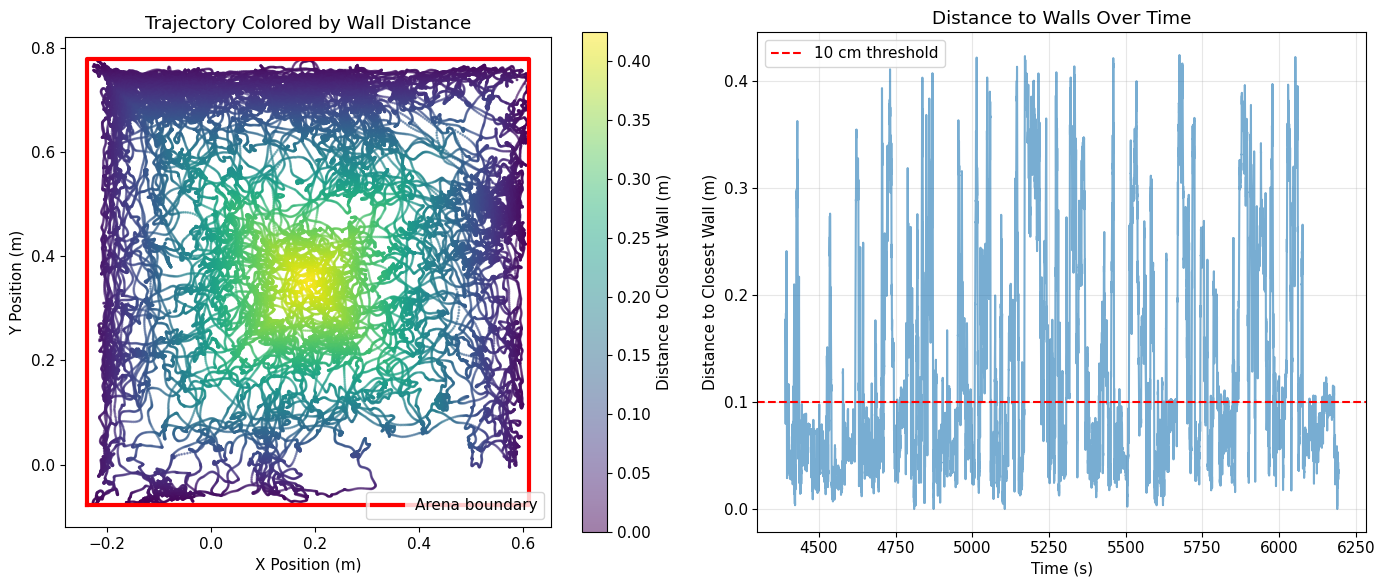

In [18]:
# Create figure
x_pos = np.array(x_pos)
y_pos = np.array(y_pos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Trajectory colored by distance to wall
ax1 = axes[0]
scatter = ax1.scatter(x_pos, y_pos, c=closest_wall_dist, 
                      s=1, cmap='viridis', alpha=0.5)
plt.colorbar(scatter, ax=ax1, label='Distance to Closest Wall (m)')

# Draw arena
ax1.plot(arena_x, arena_y, 'r-', linewidth=3, label='Arena boundary')

ax1.set_xlabel('X Position (m)')
ax1.set_ylabel('Y Position (m)')
ax1.set_title('Trajectory Colored by Wall Distance')
ax1.set_aspect('equal')
ax1.legend()

# Right: Distance over time
ax2 = axes[1]
ax2.plot(time, closest_wall_dist, alpha=0.6)
ax2.axhline(0.1, color='r', linestyle='--', label='10 cm threshold')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Distance to Closest Wall (m)')
ax2.set_title('Distance to Walls Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.3 Computing Egocentric Bearing to Walls



---
## Part 4: Egocentric Tuning of Head Direction Cells - Refer to EBR_Tutorial.ipynb 

## 4.1 Research Question

**Do HD cells encode egocentric boundary information in addition to allocentric heading?**

To test this, we'll:
1. Compute 2D tuning curves: firing rate as a function of **head direction** AND **egocentric boundary bearing**
2. Compare firing rates when walls are at different egocentric positions

### The Hypothesis

If HD cells encode **only** allocentric direction:
- Tuning should not change based on wall position

If HD cells **also** encode egocentric boundaries (as found by Alexander et al. 2020):
- Firing rates might be higher when facing toward/away from walls
- Different cells might prefer different egocentric boundary configurations

## 4.2 Computing Egocentric Tuning


In [25]:
## TODO: Egocentric spatial features

---

# Part 5: Open-Ended Exploration Projects

## Choose Your Own Adventure!

Now that you have the tools, explore one (or more) of these research questions:

### Project Option 1: Border-Proximity Effects on HD Tuning

**Question**: Do HD cells fire differently when the animal is close to walls?

**Analysis approach**:
1. Split data into "near wall" (distance < 10 cm) and "far from wall" (distance > 20 cm)
2. Compute separate HD tuning curves for each condition
3. Compare:
   - Peak firing rates
   - Preferred directions
   - Tuning width (concentration)

**Code starter**:

In [ ]:
# Project 1: Border proximity effects

# Define proximity thresholds
near_wall_threshold = 0.10  # meters
far_wall_threshold = 0.20   # meters

# Create epochs (time intervals) for each condition
near_wall_epochs = nap.IntervalSet(
    # TODO: Find time intervals where closest_wall_dist < near_wall_threshold
    # HINT: Use np.where() to find indices, then create intervals
)

far_wall_epochs = nap.IntervalSet(
    # TODO: Find time intervals where closest_wall_dist > far_wall_threshold
)

# Compute tuning curves for each condition
# tuning_near = nap.compute_tuning_curves(
#     group=hd_units,
#     feature=head_direction,
#     nb_bins=31,
#     ep=near_wall_epochs  # Restrict to near-wall times
# )

# TODO:
# - Compute tuning_far similarly
# - Compare peak rates, preferred directions
# - Visualize differences
# - Statistical test: paired t-test on peak rates

print("Complete this analysis to test for border-proximity effects!")

### Project Option 2: Behavioral State-Dependent Tuning

**Question**: Does HD cell tuning change with behavioral state (e.g., running vs. stopping)?

**Analysis approach**:
1. Compute speed from position data
2. Define states: 
   - Running: speed > 0.1 m/s
   - Stationary: speed < 0.05 m/s
3. Compare HD tuning curves between states
4. Test: Do cells maintain stable preferred directions?

**Code starter**:

In [ ]:
# Project 2: State-dependent tuning

# Compute speed
def compute_speed(x, y, dt=0.05):
    """Compute instantaneous speed from positions."""
    dx = np.diff(x)
    dy = np.diff(y)
    speed = np.sqrt(dx**2 + dy**2) / dt
    return np.concatenate([[0], speed])  # Pad to match length

# TODO:
# 1. Calculate speed
# 2. Define running and stationary epochs
# 3. Compute HD tuning for each state
# 4. Analyze:
#    - Do preferred directions shift?
#    - Does tuning sharpen during movement?
#    - Are some cells more state-dependent?

print("Explore how behavioral state affects neural tuning!")

### Project Option 3: Population-Level Egocentric Coding

**Question**: Does the population of HD cells collectively encode egocentric space?

**Analysis approach**:
1. For each neuron, compute correlation between firing rate and:
   - Egocentric bearing to north wall
   - Egocentric bearing to east wall
   - etc.
2. Cluster neurons based on their egocentric tuning profiles
3. Test: Are there distinct subpopulations?

**Code starter**:

In [ ]:
# Project 3: Population coding

# For each neuron, compute firing rate in time bins
def compute_firing_rate_timeseries(spike_times, time_bins):
    """Bin spike times and compute firing rate."""
    counts, _ = np.histogram(spike_times, bins=time_bins)
    bin_width = np.diff(time_bins).mean()
    return counts / bin_width

# TODO:
# 1. Compute firing rate time series for all neurons
# 2. For each wall, compute correlation between firing rate and:
#    - Distance to wall
#    - Egocentric bearing to wall
# 3. Create feature matrix: neurons × (4 walls × 2 features)
# 4. Cluster using:
#    - K-means
#    - Hierarchical clustering
# 5. Visualize:
#    - Dendrogram
#    - Cluster average tuning curves

print("Analyze population-level representations!")

### Project Option 4: Integrate with Behavioral Segmentation

**Question**: How do HD cells respond during different movement patterns?

**Analysis approach**:
1. Use ruptures (from Day 3) to segment trajectory
2. Classify segments as:
   - Directed runs
   - Turns
   - Pauses
3. Compare HD tuning across movement types

**Code starter**:

In [ ]:
# Project 4: Movement-type analysis

# TODO:
# 1. Segment trajectory (use ruptures library)
# 2. Classify each segment:
#    - Compute:
#      * Mean speed
#      * Path tortuosity
#      * Angular velocity
#    - Use thresholds to classify
# 3. Compute HD tuning for each movement type
# 4. Analyze:
#    - Do cells show different gain during turns?
#    - Is tuning maintained during all movements?

print("Link neural activity to movement dynamics!")

### Project Option 5: Your Own Question!

**Design your own analysis**:

Some ideas:
- Temporal dynamics: How quickly does tuning stabilize?
- Drift analysis: Does preferred direction shift over the session?
- Correlation structure: Do pairs of HD cells show coordinated activity?
- Predictive coding: Can you decode head direction from population activity?
- Cross-validation: Split data and test tuning curve stability

**Guidelines**:
1. State your hypothesis clearly
2. Design appropriate analyses
3. Visualize results effectively
4. Consider statistical tests
5. Relate back to behavioral neuroscience

In [ ]:
# Your custom analysis here!

# Tips:
# - Start simple, build complexity
# - Document your reasoning
# - Make clear visualizations
# - Check results make sense

# YOUR CODE HERE

---

# Summary & Key Takeaways

## What We Learned

### 1. Neural Data Analysis
- Loading and exploring **NWB files** with pynapple
- Understanding **spike trains** and **tuning curves**
- Computing **head direction tuning** from neural recordings

### 2. Reference Frames
- **Allocentric** (world-centered) coordinates
- **Egocentric** (body-centered) coordinates  
- Transforming between reference frames

### 3. Spatial Representations
- Head direction cells as a "neural compass"
- Computing **distance to boundaries**
- Calculating **egocentric bearings** to walls
- 2D tuning: combining allocentric and egocentric features

### 4. Integrated Analysis
- Linking **neural activity** to **behavioral states**
- Testing hypotheses about **neural coding**
- Visualizing complex, multi-dimensional data

---

## Connection to Broader Concepts

### Throughout This Workshop

**Day 1**: We learned about coordinate systems and basic kinematics
→ Today: Applied to neural-behavioral integration

**Day 2**: Pose estimation extracted body part positions
→ Today: Used position/orientation for spatial analysis

**Day 3**: Trajectory segmentation found behavioral changes
→ Today: Could test if neural tuning changes with behavior

**Day 4**: Discovered behavioral states from kinematics
→ Today: Could link states to neural representations

### The Big Picture

Understanding behavior requires understanding **both**:
1. **What the animal does** (kinematics, actions, strategies)
2. **How the brain represents it** (neural populations, reference frames, coding schemes)

Computational ethology tools let us:
- Quantify behavior objectively
- Test specific hypotheses
- Bridge levels of analysis (muscles → movements → decisions → goals)

---

## Further Reading

### Key Papers

1. **Alexander et al. (2020)** - Egocentric boundary vector tuning of the retrosplenial cortex  
   *Science Advances* - The paper inspiring today's analysis

2. **Taube et al. (1990)** - Head-direction cells recorded from the postsubiculum  
   *J. Neuroscience* - Original HD cell discovery

3. **Lever et al. (2009)** - Boundary Vector Cells in the Subiculum  
   *J. Neuroscience* - Cells encoding distance/direction to boundaries

4. **Grieves & Jeffery (2017)** - The representation of space in the brain  
   *Behavioural Processes* - Excellent review of spatial coding

### Tools & Resources

- **Pynapple documentation**: https://pynapple-org.github.io/pynapple/
- **NWB format**: https://www.nwb.org/
- **Alexander lab data**: [Link to data repository if available]

---

## Next Steps

### To Continue Learning

1. **Apply to your own data**
   - Use the techniques from this workshop
   - Adapt code for your specific questions

2. **Explore advanced topics**
   - Population decoding (predict head direction from population)
   - Bayesian inference (optimal integration of cues)
   - Dimensionality reduction (find latent structure)

3. **Combine approaches**
   - MoSeq + neural recordings
   - DLC + electrophysiology
   - Navigation strategies + place cells

4. **Read the literature**
   - Follow current papers in computational neuroscience
   - Replicate published analyses
   - Develop your own methods

---

## Acknowledgments

This tutorial is based on:
- Data from the Hasselmo lab (Boston University)
- Methods from Alexander et al. (2020)
- Pynapple library by the Peyrache lab

---

## Congratulations!

You've completed the 5-day Python for Animal Behavioral Analysis workshop! 

You now have skills in:
✅ Python programming for behavioral data
✅ Pose estimation and feature extraction
✅ Trajectory analysis and segmentation
✅ Unsupervised behavioral classification
✅ Neural-behavioral integration

**Keep exploring, keep learning, and happy analyzing! 🧠🐁📊**

---

## Workshop Feedback

Please share your thoughts:

1. What was most useful?
2. What was most challenging?
3. What topics would you like to explore further?
4. How will you apply these methods to your research?

Thank you for participating! 🎉